In [27]:
import os
import random
import xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.init as init
from kagglehub import dataset_download
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [28]:
# Weight-initialisation helper
# Apply Kaiming (He) uniform initialisation to every Conv2d and Linear layer in model.
def _apply_kaiming_init(model: nn.Module) -> None:
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            init.kaiming_uniform_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm2d):
            init.ones_(m.weight)
            init.zeros_(m.bias)
            

# YoLo copy -- Cats Only Bark Once
class coboCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        
        
        self.cobo = nn.Sequential(
            # dont forget activations
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(16),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(32,64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(64,64,kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
        )
        
        # LeNet-5 Original classifier
        self.classifier = nn.Sequential(
            
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.Linear(1_568, 512),
            nn.Sigmoid(),
            nn.Linear(512, 343),
        )

        # Apply initialization
        self._apply_kaiming_init()
        
    def _apply_kaiming_init(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cobo(x)
        x = x.view(x.size(0), -1) # Flattens feature maps
        x = self.classifier(x)
        return x

In [29]:
# Download the dataset locally
dataset_dir = Path(kagglehub.dataset_download("andrewmvd/dog-and-cat-detection"))
print(f"Dataset downloaded to: {dataset_dir.resolve()}")

# Preview top-level files/folders.
for item in sorted(dataset_dir.iterdir()):
    print(f"- {item.name}")

Dataset downloaded to: C:\Users\kiann\.cache\kagglehub\datasets\andrewmvd\dog-and-cat-detection\versions\1
- annotations
- images


In [30]:

# Try to import refactored utilities from repo; fallback to definitions below
try:
    from src.data_processing import resize_and_pad_image, transform_bbox, process_record, split_train_val, visualize_sample
except Exception:
    
    def resize_and_pad_image(img: Image.Image, size=(112,112)):
        W,H=size; w,h=img.size
        scale=min(W/w,H/h)
        new_w=max(1,int(round(w*scale))); new_h=max(1,int(round(h*scale)))
        img_resized=img.resize((new_w,new_h),Image.BILINEAR)
        pad_left=(W-new_w)//2; pad_top=(H-new_h)//2
        canvas=Image.new("RGB",(W,H),(0,0,0)); canvas.paste(img_resized,(pad_left,pad_top))
        return canvas,scale,pad_left,pad_top
    
    def transform_bbox(bbox,scale,pad_left,pad_top):
        xmin,ymin,xmax,ymax=bbox
        return (max(0,int(round(xmin*scale+pad_left))),
                max(0,int(round(ymin*scale+pad_top))),
                max(0,int(round(xmax*scale+pad_left))),
                max(0,int(round(ymax*scale+pad_top))))
    
    def process_record(image_path, bbox, out_path, size=(112,112)):
        img=Image.open(image_path).convert("RGB")
        orig_w,orig_h=img.size
        canvas,scale,pad_left,pad_top=resize_and_pad_image(img,size=size)
        xmin,ymin,xmax,ymax=transform_bbox(bbox,scale,pad_left,pad_top)
        out_path.parent.mkdir(parents=True,exist_ok=True)
        canvas.save(out_path)
        return {"image_path":str(out_path),"orig_w":orig_w,"orig_h":orig_h,"scale":float(scale),
                "pad_left":int(pad_left),"pad_top":int(pad_top),"xmin":int(xmin),"ymin":int(ymin),
                "xmax":int(xmax),"ymax":int(ymax)}
    
    

    def split_train_val(df, stratify_col="label", val_frac=0.2, random_state=42):
        if stratify_col in df.columns:
            t,v = train_test_split(df, test_size=val_frac, stratify=df[stratify_col], random_state=random_state)
        else:
            t,v = train_test_split(df, test_size=val_frac, random_state=random_state)
        return t.reset_index(drop=True), v.reset_index(drop=True)
    
    def visualize_sample(img_path, bbox, ax=None, show=False):
        if ax is None:
            fig, ax = plt.subplots()
        
        img = plt.imread(img_path)
        ax.imshow(img)
        
        # Draw your bounding box (example using patches)
        import matplotlib.patches as patches
        xmin, ymin, xmax, ymax = bbox
        rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, 
                                linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        
        if show:
            plt.show()

In [31]:
dataset_dir = Path(dataset_download("andrewmvd/dog-and-cat-detection"))
print("Dataset dir:", dataset_dir.resolve())
for p in sorted(dataset_dir.iterdir()):
    print("-", p.name)

Dataset dir: C:\Users\kiann\.cache\kagglehub\datasets\andrewmvd\dog-and-cat-detection\versions\1
- annotations
- images


In [32]:
for p in dataset_dir.rglob("*.csv"):
    df_check = pd.read_csv(p, nrows=0) # Only reads header
    print(f"File: {p.name} | Columns: {list(df_check.columns)}")

In [33]:
# Find all XML files
xml_files = list(dataset_dir.rglob("*.xml"))
print(f"Found {len(xml_files)} XML files.")

data = []

for xml_path in tqdm(xml_files, desc="Processing XMLs"):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    file_name = root.find('filename').text
    
    for obj in root.findall('object'):
        label = obj.find('name').text
        bbox = obj.find('bndbox')

        data.append({
            'filename': file_name,
            'class': label,
            'xmin': int(bbox.find('xmin').text),
            'ymin': int(bbox.find('ymin').text),
            'xmax': int(bbox.find('xmax').text),
            'ymax': int(bbox.find('ymax').text)
        })

# 3. Create the DataFrame
df = pd.DataFrame(data)
print(f"\nLoaded annotations shape: {df.shape}")
print(df.head())

Found 3686 XML files.


Processing XMLs: 100%|██████████| 3686/3686 [00:00<00:00, 14390.89it/s]


Loaded annotations shape: (3687, 6)
            filename class  xmin  ymin  xmax  ymax
0     Cats_Test0.png   cat    83    29   197   142
1     Cats_Test1.png   dog   128    22   240   222
2    Cats_Test10.png   dog   157    56   264   116
3   Cats_Test100.png   cat   142   145   206   209
4  Cats_Test1000.png   cat    36    14   289   312


In [34]:
# Expected final columns: image, label, xmin, ymin, xmax, ymax
colmap = {}
if 'file_name' in df.columns and 'label' in df.columns: colmap['file_name'] = 'image'
if 'image' not in df.columns: colmap[df.columns[0]] = 'image'
if 'class' in df.columns: colmap['class'] = 'label'
if 'x1' in df.columns: colmap['x1'] = 'xmin'
if 'y1' in df.columns: colmap['y1'] = 'ymin'
if 'x2' in df.columns: colmap['x2'] = 'xmax'
if 'y2' in df.columns: colmap['y2'] = 'ymax'
df = df.rename(columns=colmap)
required = {'image','label','xmin','ymin','xmax','ymax'}
if not required.issubset(set(df.columns)):
    raise ValueError(f"Annotations missing required columns: {required - set(df.columns)}")
# make image paths absolute if necessary
df['image'] = df['image'].apply(lambda p: str((dataset_dir / p) if not Path(p).is_absolute() else Path(p)))

In [35]:
train_df, val_df = split_train_val(df, stratify_col='label', val_frac=0.2, random_state=42)
print("Train/Val sizes:", len(train_df), len(val_df))

Train/Val sizes: 2949 738


In [36]:
# check if we have any overlap between train and val sets
overlap = set(train_df['image']) & set(val_df['image'])
print(f"Number of overlapping images: {len(overlap)}")
# should be 0

Number of overlapping images: 0


In [37]:
# Define output paths
out_dir = Path("data/processed")
train_out_dir = out_dir / "train"
val_out_dir = out_dir / "val"

# Ensure directories exist
train_out_dir.mkdir(parents=True, exist_ok=True)
val_out_dir.mkdir(parents=True, exist_ok=True)

train_rows = []
val_rows = []

def process_df_rows(df_in, dst_dir, rows_out):
    pbar = tqdm(df_in.iterrows(), total=len(df_in), desc=f"Processing {dst_dir.name}")
    
    for i, r in pbar:
        img_path = dataset_dir / "images" / Path(r['image']).name
        
        if not img_path.exists():
            continue
            
        fname = img_path.name
        dst = dst_dir / fname
        bbox = (float(r['xmin']), float(r['ymin']), float(r['xmax']), float(r['ymax']))
        
        meta = process_record(img_path, bbox, dst, size=(112, 112))
        
        meta['label'] = r['label']
        rows_out.append(meta)

# Run processing for both splits
process_df_rows(train_df, train_out_dir, train_rows)
process_df_rows(val_df, val_out_dir, val_rows)

# Create new DataFrames and save to CSV
train_processed_df = pd.DataFrame(train_rows)
val_processed_df = pd.DataFrame(val_rows)

train_processed_df.to_csv(out_dir / "train.csv", index=False)
val_processed_df.to_csv(out_dir / "val.csv", index=False)

print(f"Successfully saved {len(train_processed_df)} train and {len(val_processed_df)} val records.")
print(f"Processed data located at: {out_dir.resolve()}")

Processing val: 100%|██████████| 738/738 [00:04<00:00, 164.54it/s]

Successfully saved 2949 train and 738 val records.
Processed data located at: C:\Users\kiann\Documents\.Education\UU\Courses\INFOCV\Assignments\04_UU_CV_Dog_Cat_Object_Detection\notebooks\data\processed


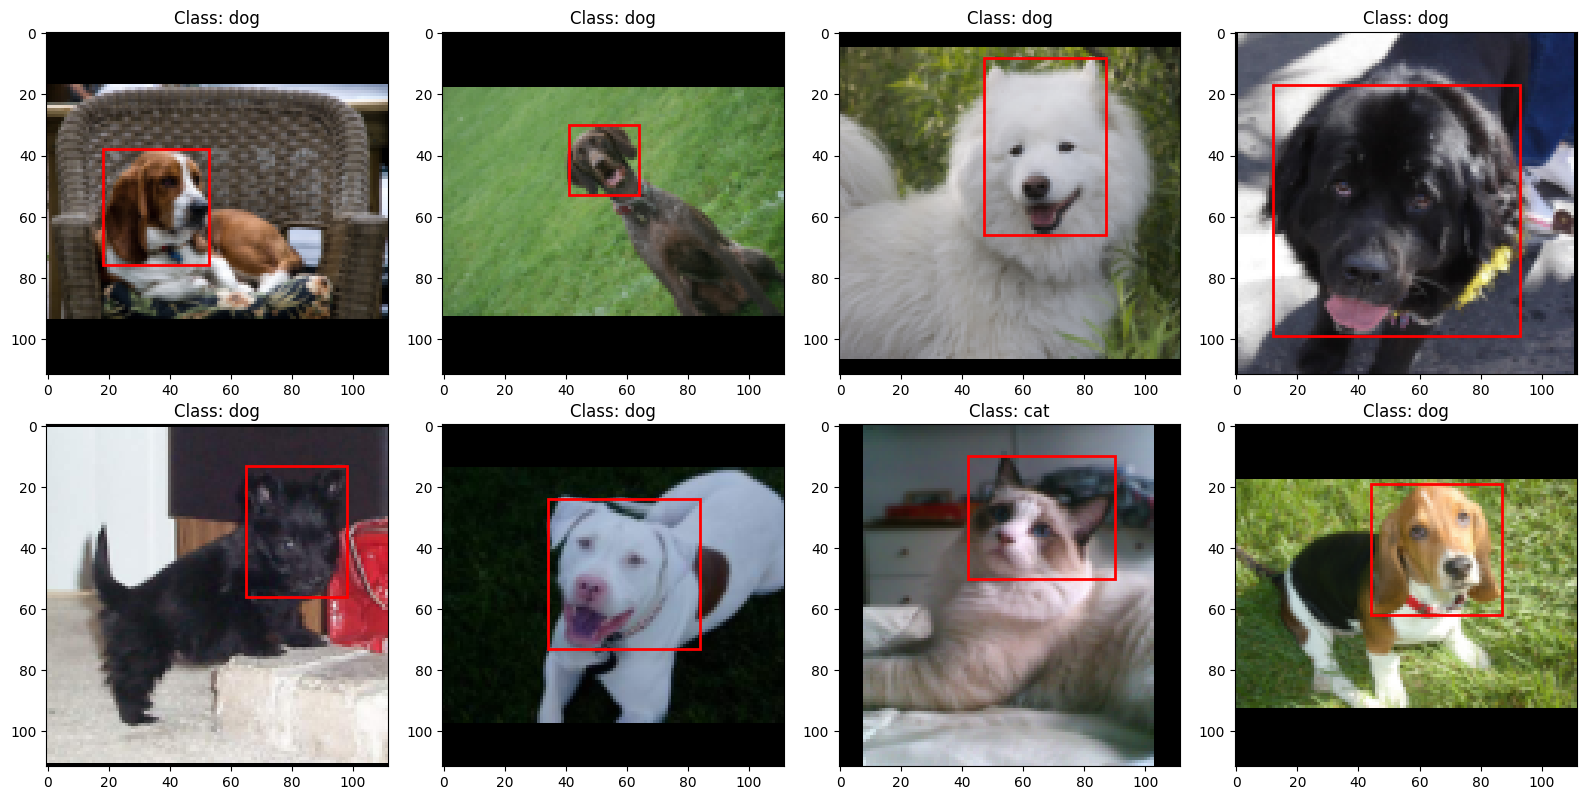

In [38]:
# Setup sample data
num_samples = min(8, len(proc_df))
indices = random.sample(range(len(proc_df)), num_samples)

# Create the figure and grid (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()  # Flatten to easily loop with a single index

for i, idx in enumerate(indices):
    row = proc_df.iloc[idx]
    img_p = Path(row['image_path'])
    bbox = (int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax']))
    visualize_sample(img_p, bbox, ax=axes[i])
    axes[i].set_title(f"Class: {row.get('label', 'N/A')}")

# Clean up layout
plt.tight_layout()
plt.show()